<a href="https://colab.research.google.com/github/kidais-lab/Mad-Libs-Generator/blob/master/Project3_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 3 — Data Visualization with Matplotlib and Seaborn.**

**Dataset**: Prosper Loan Data (CSV)

**Goal**:
*   Part I: Explore the data using various visualizations
*   Part II: Create polished plots to tell a clear story about key findings

# **PART I: EXPLORATORY VISUALIZATION**

**INTRODUCTION**:

**What is this dataset about?**
The Prosper Loan Data contains info about loans issued by Prosper Marketplace. It includes borrower info, loan status, credit scores, income, and more. The goal is to explore borrower behavior, loan performance, and key patterns.

**I want to find out:**

*   What is the distribution of loan amounts and interest rates?
*   How does credit score relate to interest rate?
*   Do borrower incomes affect loan status?
*   What other factors impact default risk?

# **PRELIMINARY WRANGLING**

In [28]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# LOAD DATA
df = pd.read_csv('prosperLoanData.csv')

In [30]:
# OVERVIEW
print(df.shape)
print(df.info())

(113937, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  

In [31]:
# SELECT RELEVANT COLUMNS for analysis
columns = [
    'LoanOriginalAmount', 'BorrowerAPR', 'BorrowerRate',
    'ProsperRating (Alpha)', 'ProsperScore',
    'ListingCategory (numeric)', 'Term',
    'EmploymentStatus', 'IncomeRange',
    'StatedMonthlyIncome', 'LoanStatus',
    'CreditGrade', 'DebtToIncomeRatio'
           ]

In [32]:
df = df[columns]

In [33]:
# CLEAN UP: drop missing rows in key columns
df.dropna(subset=['BorrowerRate', 'LoanOriginalAmount'], inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   LoanOriginalAmount         113937 non-null  int64  
 1   BorrowerAPR                113912 non-null  float64
 2   BorrowerRate               113937 non-null  float64
 3   ProsperRating (Alpha)      84853 non-null   object 
 4   ProsperScore               84853 non-null   float64
 5   ListingCategory (numeric)  113937 non-null  int64  
 6   Term                       113937 non-null  int64  
 7   EmploymentStatus           111682 non-null  object 
 8   IncomeRange                113937 non-null  object 
 9   StatedMonthlyIncome        113937 non-null  float64
 10  LoanStatus                 113937 non-null  object 
 11  CreditGrade                28953 non-null   object 
 12  DebtToIncomeRatio          105383 non-null  float64
dtypes: float64(5), int64(3), obje

# **UNIVARIATE EXPLORATION**

**Histogram (loan amount)**

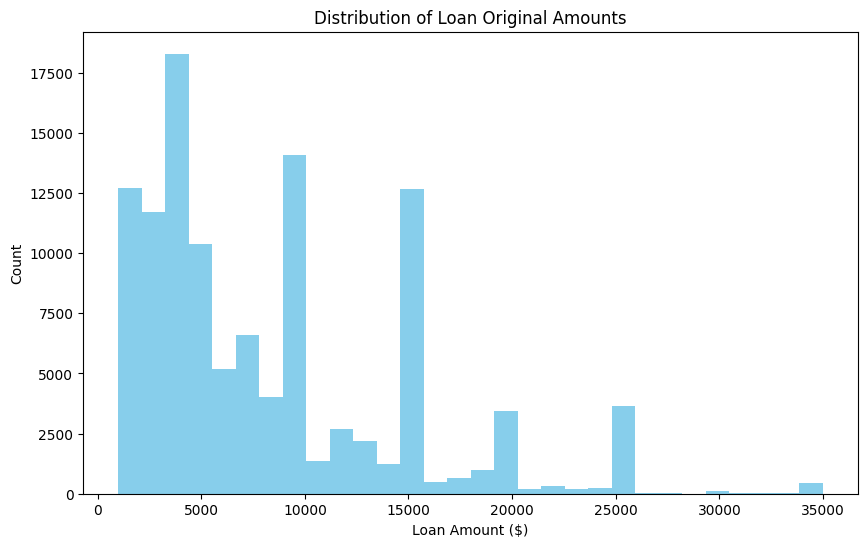

In [20]:
# HISTOGRAM: Loan Original Amount
plt.figure(figsize=(10,6))
plt.hist(df['LoanOriginalAmount'], bins=30, color='skyblue')
plt.title('Distribution of Loan Original Amounts')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.show()

**Bar chart / count plot (loan status)**

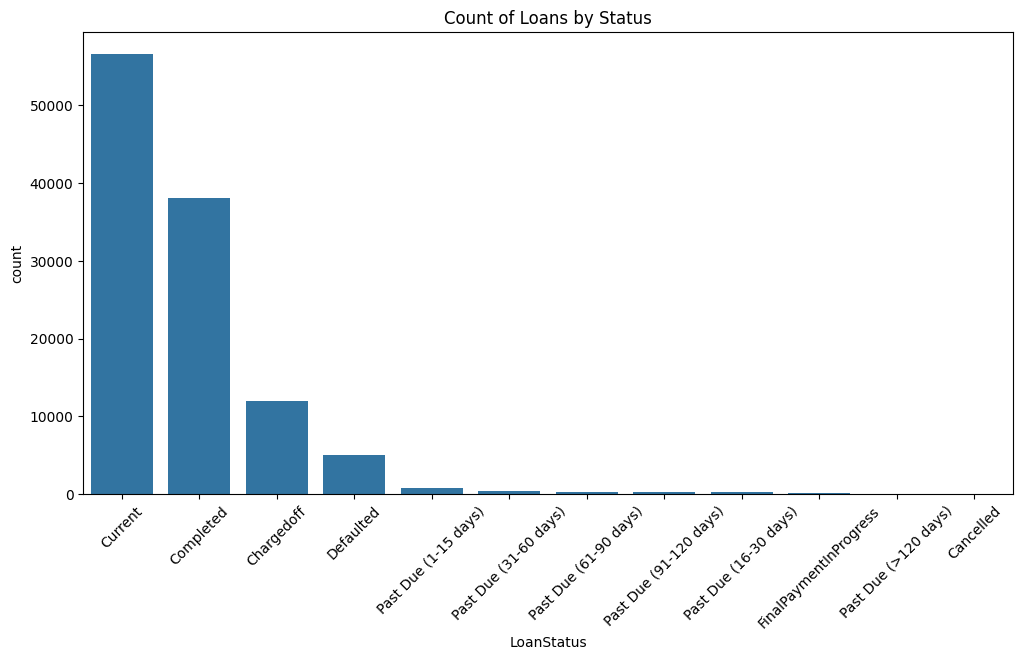

In [22]:
# COUNT PLOT: Loan Status
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='LoanStatus', order=df['LoanStatus'].value_counts().index)
plt.title('Count of Loans by Status')
plt.xticks(rotation=45)
plt.show()

**scatterplot**

# **BIVARIATE EXPLORATION**

**Scatter plot (APR vs. Loan Amount)**

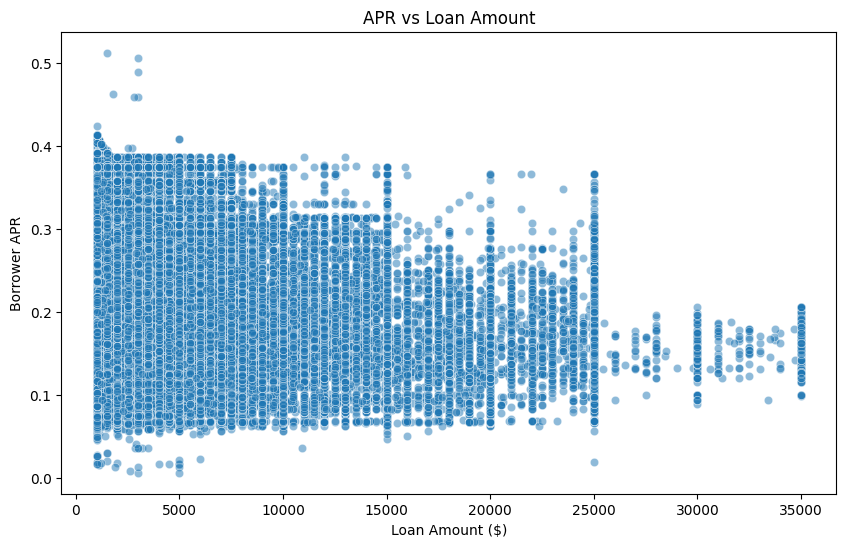

In [23]:
# SCATTER PLOT: APR vs Loan Amount
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='LoanOriginalAmount', y='BorrowerAPR', alpha=0.5)
plt.title('APR vs Loan Amount')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Borrower APR')
plt.show()

**Box plot (APR by Prosper Rating)**

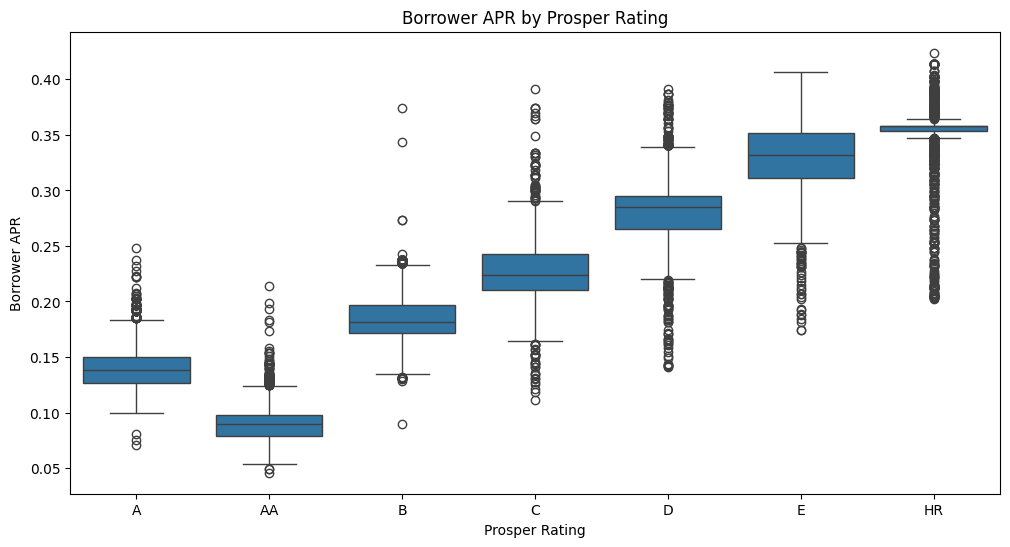

In [24]:
# BOX PLOT: APR by Prosper Rating
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='ProsperRating (Alpha)', y='BorrowerAPR',
            order=sorted(df['ProsperRating (Alpha)'].dropna().unique()))
plt.title('Borrower APR by Prosper Rating')
plt.xlabel('Prosper Rating')
plt.ylabel('Borrower APR')
plt.show()

**Heatmap or clustered bar chart**

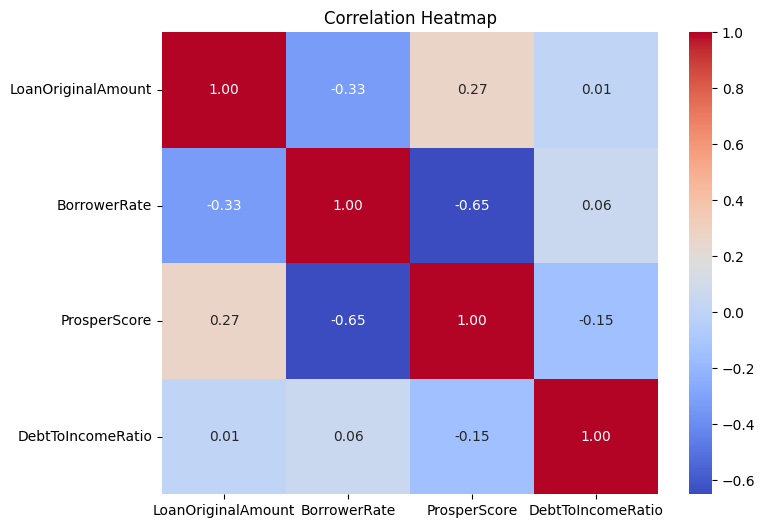

In [25]:
# HEATMAP: Correlation of numeric features
numeric = df[['LoanOriginalAmount', 'BorrowerRate', 'ProsperScore', 'DebtToIncomeRatio']]
corr = numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# **MULTIVARIATE EXPLORATION**

**Facet plot (scatter of APR vs Loan Amount by Prosper Rating**

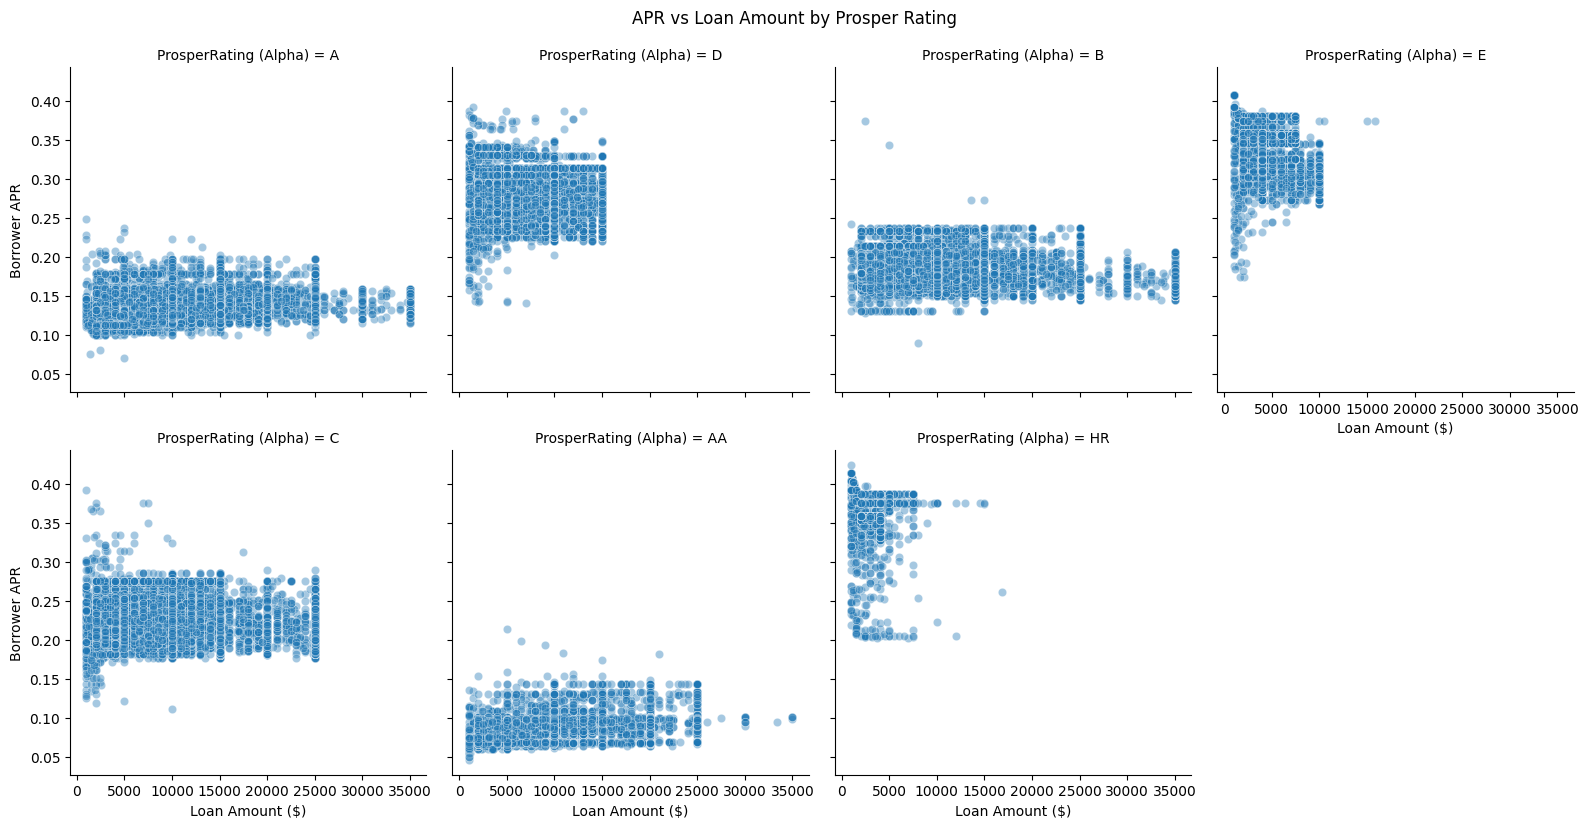

In [26]:
# FACET PLOT: APR vs Loan Amount by Prosper Rating
g = sns.FacetGrid(df, col='ProsperRating (Alpha)', col_wrap=4, height=4)
g.map(sns.scatterplot, 'LoanOriginalAmount', 'BorrowerAPR', alpha=0.4)
g.set_axis_labels('Loan Amount ($)', 'Borrower APR')
g.fig.suptitle('APR vs Loan Amount by Prosper Rating', y=1.03)
plt.show()

**scatterplot with multiple encodings**

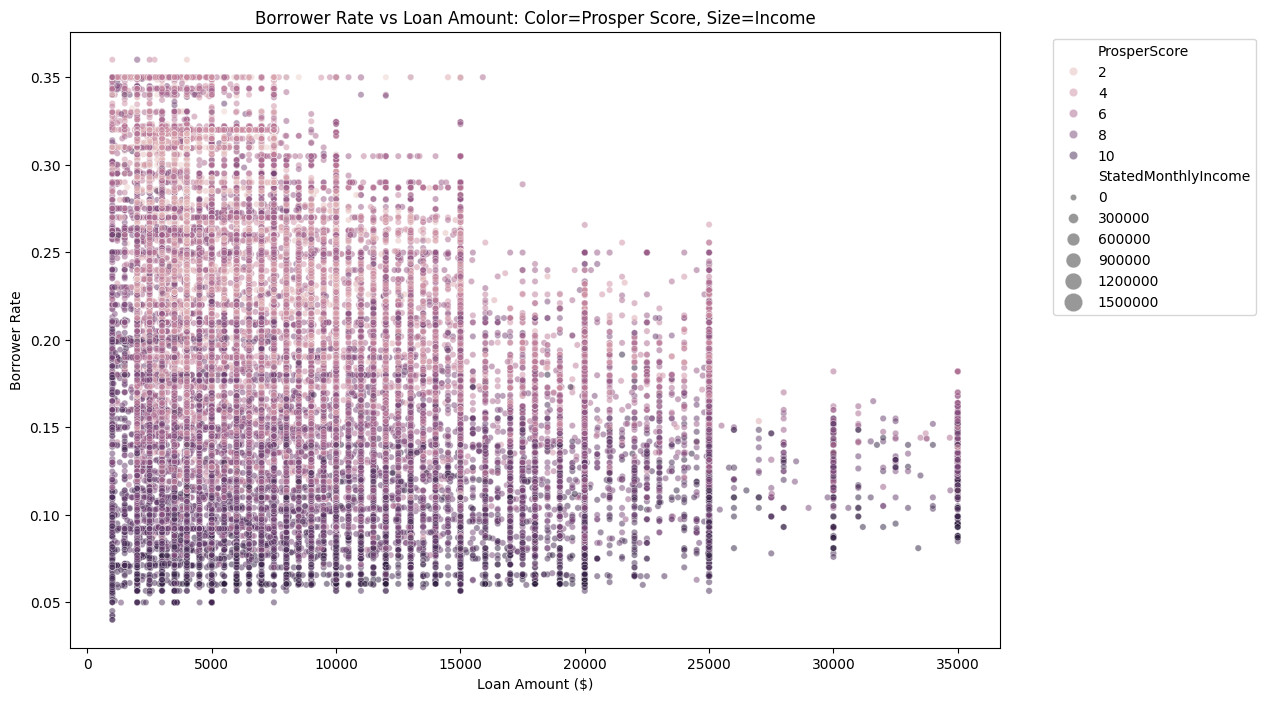

In [27]:
# SCATTERPLOT with multiple encodings: Size = Income, Color = Prosper Score
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=df,
    x='LoanOriginalAmount',
    y='BorrowerRate',
    hue='ProsperScore',
    size='StatedMonthlyIncome',
    sizes=(20, 200),
    alpha=0.5
                   )
plt.title('Borrower Rate vs Loan Amount: Color=Prosper Score, Size=Income')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Borrower Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# **Explanatory data visualization**

The Explanatory of the above data visualization and the answers to the project questions are attached in a separe pdf file (Explanatory data visualization By khalaf idais)

**Thanks alot**